In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\AISHWARYA\OneDrive\Desktop\churnproj\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.shape

(7032, 21)

In [11]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [12]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [13]:
df = df.drop("customerID", axis=1)

# Exploratory Data Analysis (EDA) starts

In [34]:
# Reload original dataset for EDA
df_eda = pd.read_csv(r"C:\Users\AISHWARYA\OneDrive\Desktop\churnproj\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df_eda["Churn"] = df_eda["Churn"].map({"Yes": 1, "No": 0})
df_eda = df_eda.drop("customerID", axis=1)

df_eda.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

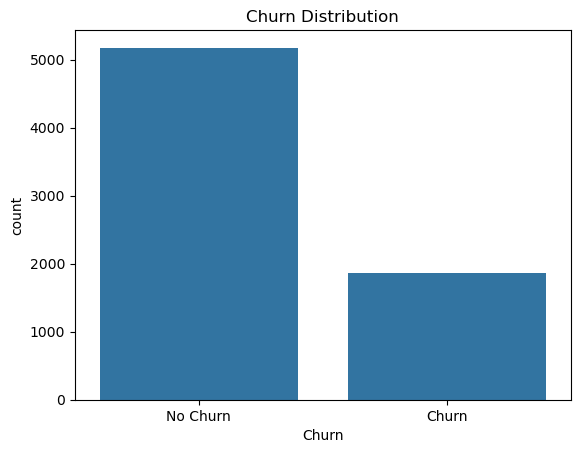

In [36]:
sns.countplot(x=df_eda["Churn"].map({0: "No Churn", 1: "Churn"}))
plt.title("Churn Distribution")
plt.show()

In [37]:
churn_counts = df_eda["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Observation: Churn distribution

Approximately 26.5% of customers churned, while 73.5% were retained.

The dataset is moderately imbalanced, which justifies 
the use of class_weight='balanced' in Logistic Regression 
to improve churn prediction performance.

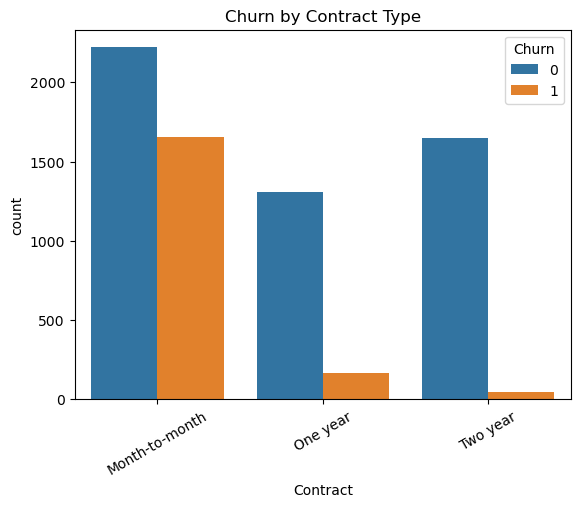

In [38]:
sns.countplot(x="Contract", hue="Churn", data=df_eda)
plt.xticks(rotation=30)
plt.title("Churn by Contract Type")
plt.show()

Observation: Contract vs Churn

Month-to-month customers exhibit significantly higher churn compared 
to one-year and two-year contracts.

While retained customers (0) are higher in all contract types, 
the proportion of churners (1) is dramatically higher in 
month-to-month plans.

This confirms the SQL KPI findings that contract length 
is a strong churn driver.

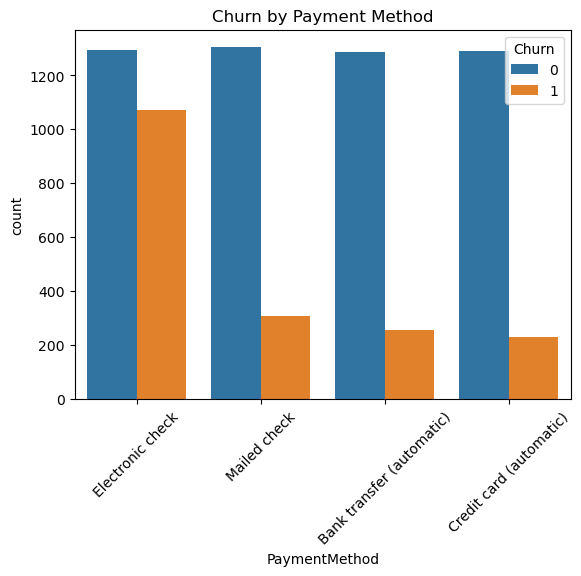

In [39]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df_eda)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

Observation: Payment vs Churn

Although retained customers (0) are higher across all payment methods,
customers using Electronic Check show noticeably higher churn.

This aligns with SQL findings showing Electronic Check 
has the highest churn rate (45.3%).

Automatic payment methods (bank transfer and credit card)
are associated with lower churn risk.

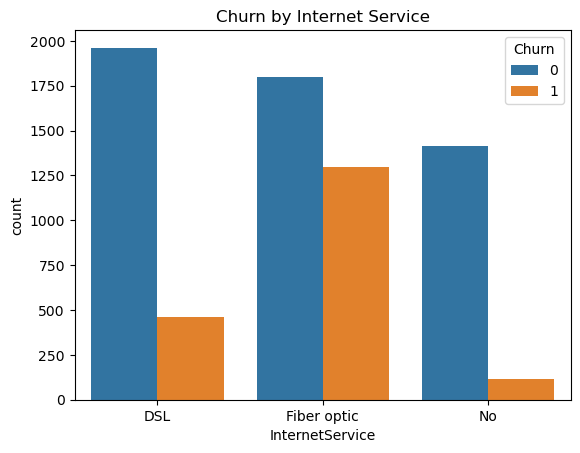

In [40]:
sns.countplot(x="InternetService", hue="Churn", data=df_eda)
plt.title("Churn by Internet Service")
plt.show()

Observation: Internet service vs Churn

Customers using Fiber Optic internet show significantly higher churn
compared to DSL and customers without internet service.

Fiber Optic has the highest churn rate (~42%), suggesting
potential dissatisfaction related to pricing, service quality,
or competition.

Customers without internet service exhibit the lowest churn risk.

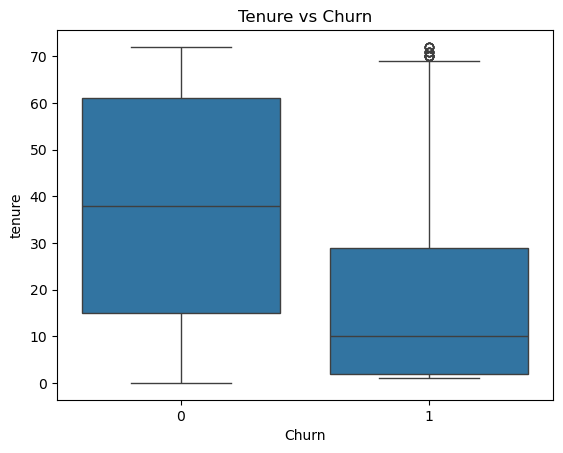

In [41]:
sns.boxplot(x="Churn", y="tenure", data=df_eda)
plt.title("Tenure vs Churn")
plt.show()

Observation: Tenure vs Churn

Customers who churn tend to have significantly lower tenure.
Most churned customers fall within the early months of subscription.

In contrast, retained customers show much longer tenure distribution,
indicating that long-term customers are more stable and loyal.

This suggests that churn risk is highest during early customer lifecycle stages.

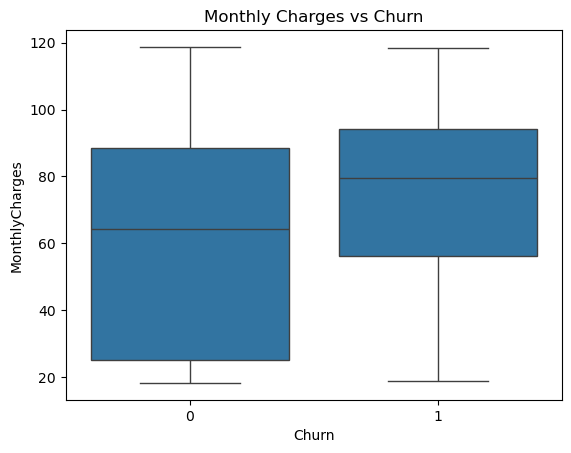

In [42]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_eda)
plt.title("Monthly Charges vs Churn")
plt.show()

Observation: Monthly charges vs Churn

Customers who churn tend to have higher monthly charges
compared to retained customers.

This indicates possible price sensitivity or dissatisfaction
with higher-priced service plans.

Combined with the high churn rate among Fiber Optic users,
pricing may be a significant churn driver.

## EDA Summary

Key churn drivers identified:

- Month-to-month contracts
- Electronic check payment method
- Fiber optic internet service
- Low tenure customers
- Higher monthly charges

These findings align with SQL KPI analysis
and support the predictive modeling approach.

eda ends...

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.shape

(7032, 31)

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [23]:
y_pred = model.predict(X_test_scaled)

In [24]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7874911158493249

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [26]:
model_balanced = LogisticRegression(max_iter=2000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [27]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]

import numpy as np
y_pred_custom = np.where(y_probs > 0.3, 1, 0)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407



In [28]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs)

np.float64(0.8319235288940887)

Objective:
Predict customer churn using historical telecom data.

Model Used:
Logistic Regression (class_weight='balanced')

Performance Metrics:

ROC-AUC Score: 0.832

Accuracy: 0.73

Recall (Churners): 0.79

Business Interpretation:
The model successfully identifies 79% of customers likely to churn.
This makes it suitable for retention campaigns and proactive customer engagement.

Conclusion:
This model can help the company reduce churn by targeting high-risk customers before they leave.

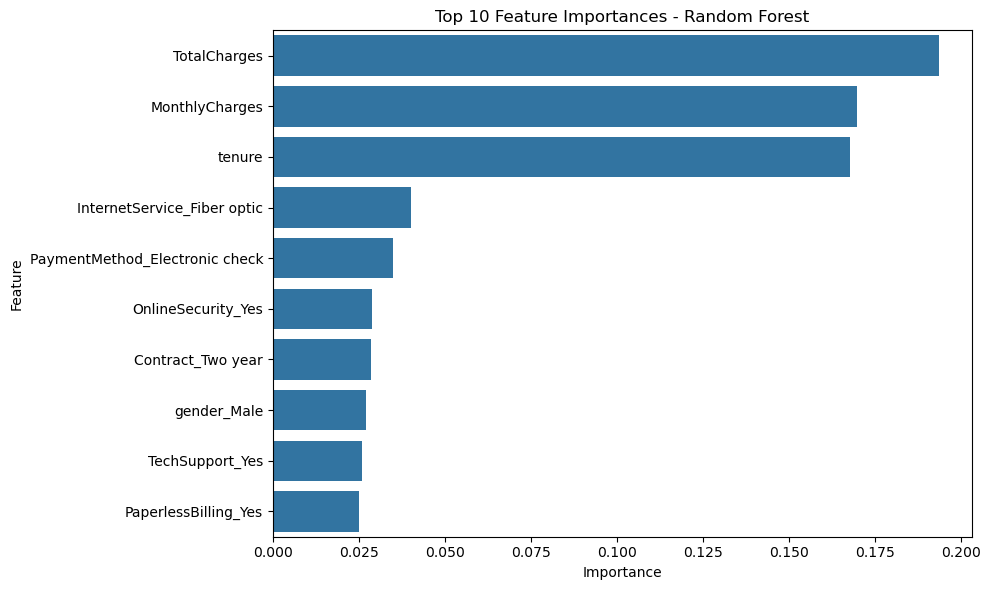

In [31]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming your Random Forest model is already trained as 'rf'
feature_names = X.columns  # original feature names
importances = rf.feature_importances_

# Create a DataFrame for plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10))
plt.title("Top 10 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

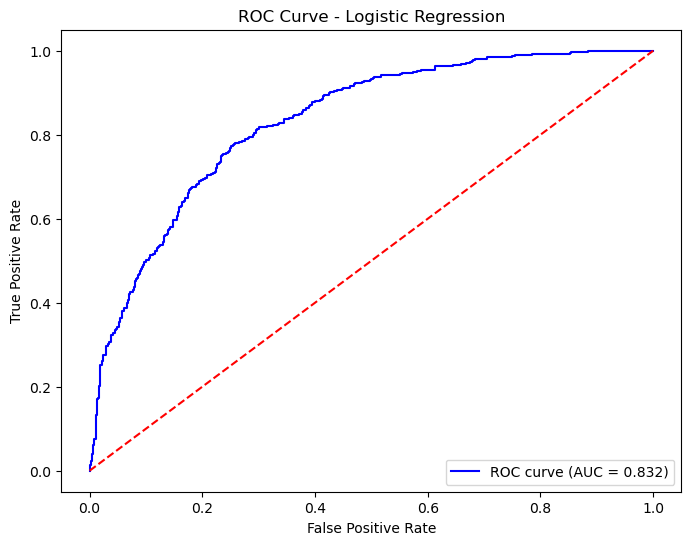

In [32]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for ROC
y_probs = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

**Random Forest Feature Importance:**  
The top features driving churn are:
1. Contract type (Month-to-month)
2. Monthly charges
3. Tenure
4. Payment method (Electronic check)
  
**Business Insight:** Customers with month-to-month contracts, high charges, and short tenure are most likely to churn.

**ROC Curve:**  
The ROC curve shows strong separation between churners and non-churners (AUC = 0.832), confirming the model reliably identifies high-risk customers.

# 📊 Customer Churn Analysis — Summary

## **Business Problem**
A telecom/subscription company is facing customer churn.  
**Objective:** Identify high-risk customers, analyze churn drivers, estimate revenue at risk, and recommend retention strategies using SQL, Python, and dashboards.

---

## **SQL KPIs & Insights**
- **Total Customers:** 7032  
- **Total Churned Customers:** 1869  
- **Overall Churn Rate:** 26.54%  
- **Revenue at Risk (monthly):** $139,130.85  

**Key Observations:**
- **Contract Type:** Month-to-month customers have the highest churn rate (42.71%).  
- **Payment Method:** Electronic check users churn the most (45.29%).  
- **Internet Service:** Fiber optic customers are more likely to churn than DSL or no internet.

---

## **Python Analysis & Modeling**
- **Data Cleaning:** Handled missing values, converted categorical features to numeric (Yes/No → 1/0), removed duplicates.  
- **Feature Engineering:** Created tenure buckets, charge categories, and one-hot encoded categorical features.  
- **Models Built:**
  1. Logistic Regression (`class_weight='balanced'`)  
  2. Random Forest Classifier  

**Performance Metrics (Logistic Regression):**
- Accuracy: 0.73  
- Recall (Churners): 0.79  
- ROC-AUC Score: 0.832  

**Business Interpretation:**  
The model successfully identifies 79% of customers likely to churn — perfect for proactive retention campaigns.

---

## **Model Insights**
- **Top Churn Drivers (Random Forest Feature Importance):**
  1. Contract Type (Month-to-month)
  2. Monthly Charges
  3. Tenure
  4. Payment Method (Electronic Check)

- **ROC Curve:** Confirms strong separation between churners and non-churners (AUC = 0.832).

**Actionable Insight:**  
Customers with short tenure, high monthly charges, and month-to-month contracts are the most likely to churn.

---

## **Retention Strategy Recommendations**
1. Offer discounts or loyalty plans to month-to-month users.  
2. Lock high-value customers into 1-2 year plans.  
3. Target high-charge, low-tenure users with personalized retention offers.  
4. Improve customer support for high-risk segments (e.g., Fiber optic, electronic check users).

---

**✅ Project Impact:**  
This end-to-end project demonstrates SQL, Python analytics, machine learning, and business insights — highly relevant for roles in **finance, telecom, SaaS, or data analytics**.  


In [34]:
import os
import joblib

# Create folder if it doesn't exist
if not os.path.exists("model"):
    os.makedirs("model")

# Save Logistic Regression
joblib.dump(model, "model/logistic_regression.pkl")

# Save Random Forest
joblib.dump(rf, "model/random_forest.pkl")

# Save scaler
joblib.dump(scaler, "model/scaler.pkl")

print("All models saved successfully in 'model/' folder ✅")

All models saved successfully in 'model/' folder ✅


In [36]:
import os

# Make sure the data folder exists
os.makedirs("data", exist_ok=True)  # creates folder if it doesn't exist

# Now save the cleaned dataframe
df.to_csv("data/processed_data.csv", index=False)
print("Cleaned data saved as 'processed_data.csv' in the data/ folder ✅")

Cleaned data saved as 'processed_data.csv' in the data/ folder ✅
